## LOAN DATA ANALYSIS AND MODELING

In [ ]:
# Install packages and call libraries
install.packages(c("tidyverse", "caret", "corrplot", "car", "MASS", "ROCR"))

library(tidyverse)
library(caret)
library(corrplot)
library(car)
library(MASS)
library(ROCR)
library(dplyr)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Load and display dataset
data <- read.csv("/content/sample_data/loan_data.csv")

head(data)
summary(data)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
,<dbl>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<int>
1,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
2,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
3,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
4,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
5,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1
6,21,female,High School,12951,0,OWN,2500,VENTURE,7.14,0.19,2,532,No,1


   person_age     person_gender      person_education   person_income    
 Min.   : 20.00   Length:45000       Length:45000       Min.   :   8000  
 1st Qu.: 24.00   Class :character   Class :character   1st Qu.:  47204  
 Median : 26.00   Mode  :character   Mode  :character   Median :  67048  
 Mean   : 27.76                                         Mean   :  80319  
 3rd Qu.: 30.00                                         3rd Qu.:  95789  
 Max.   :144.00                                         Max.   :7200766  
 person_emp_exp   person_home_ownership   loan_amnt     loan_intent       
 Min.   :  0.00   Length:45000          Min.   :  500   Length:45000      
 1st Qu.:  1.00   Class :character      1st Qu.: 5000   Class :character  
 Median :  4.00   Mode  :character      Median : 8000   Mode  :character  
 Mean   :  5.41                         Mean   : 9583                     
 3rd Qu.:  8.00                         3rd Qu.:12237                     
 Max.   :125.00                 

### Data cleaning

In [ ]:
# Check for missing value
colSums(is.na(data))

# Changing categorical data to numerical data
data$person_gender <- as.factor(data$person_gender)
data$person_education <- as.factor(data$person_education)
data$person_home_ownership <- as.factor(data$person_home_ownership)
data$loan_intent <- as.factor(data$loan_intent)
data$previous_loan_defaults_on_file <- as.factor(data$previous_loan_defaults_on_file)
data$loan_status <- as.factor(data$loan_status)

#Summary
summary(data)


person_age                  person_gender 
                             0                              0 
              person_education                  person_income 
                             0                              0 
                person_emp_exp          person_home_ownership 
                             0                              0 
                     loan_amnt                    loan_intent 
                             0                              0 
                 loan_int_rate            loan_percent_income 
                             0                              0 
    cb_person_cred_hist_length                   credit_score 
                             0                              0 
previous_loan_defaults_on_file                    loan_status 
                             0                              0

   person_age     person_gender     person_education person_income    
 Min.   : 20.00   female:20159   Associate  :12028   Min.   :   8000  
 1st Qu.: 24.00   male  :24841   Bachelor   :13399   1st Qu.:  47204  
 Median : 26.00                  Doctorate  :  621   Median :  67048  
 Mean   : 27.76                  High School:11972   Mean   :  80319  
 3rd Qu.: 30.00                  Master     : 6980   3rd Qu.:  95789  
 Max.   :144.00                                      Max.   :7200766  
 person_emp_exp   person_home_ownership   loan_amnt    
 Min.   :  0.00   MORTGAGE:18489        Min.   :  500  
 1st Qu.:  1.00   OTHER   :  117        1st Qu.: 5000  
 Median :  4.00   OWN     : 2951        Median : 8000  
 Mean   :  5.41   RENT    :23443        Mean   : 9583  
 3rd Qu.:  8.00                         3rd Qu.:12237  
 Max.   :125.00                         Max.   :35000  
            loan_intent   loan_int_rate   loan_percent_income
 DEBTCONSOLIDATION:7145   Min.   : 5.42   Min.   

### EDA

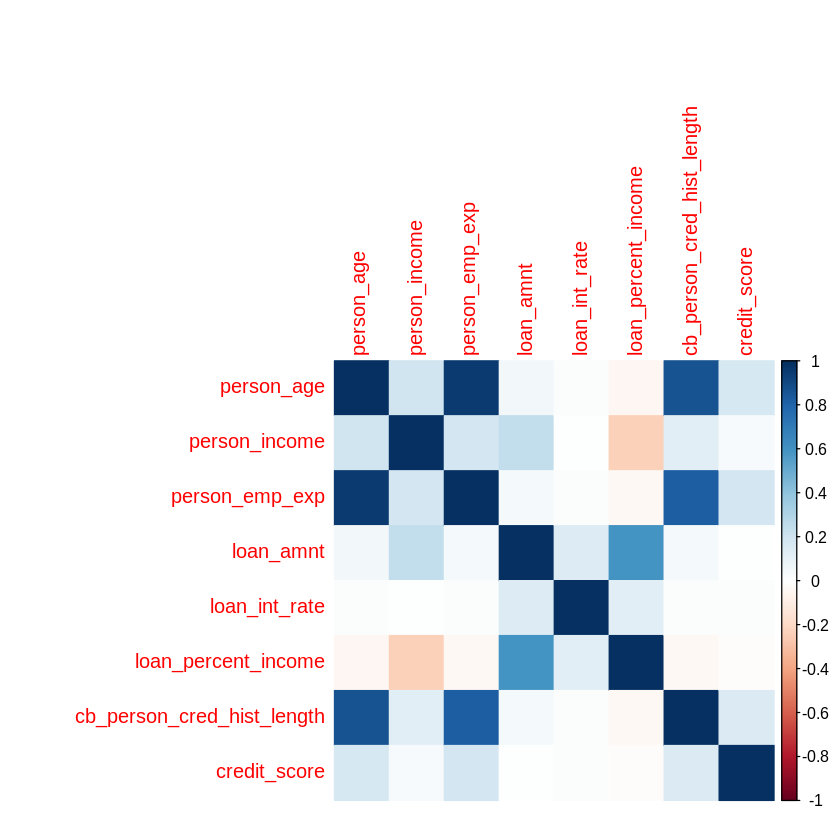

In [ ]:
# Correlation
numeric_data <- data %>% dplyr::select(where(is.numeric))

cor_matrix <- cor(numeric_data)
corrplot(cor_matrix, method = "color")

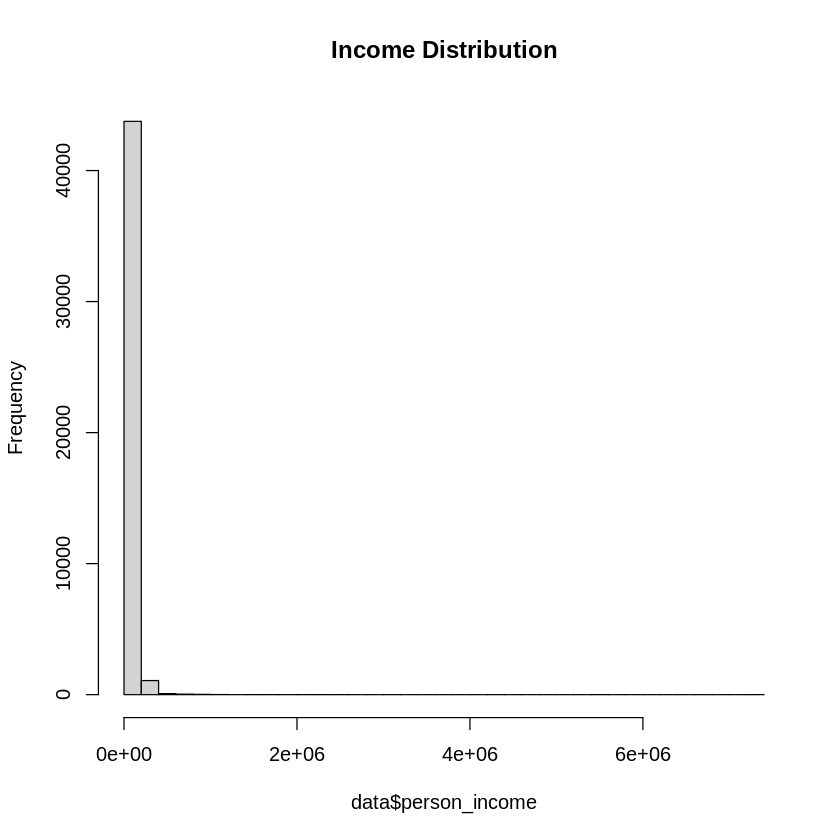

In [ ]:
# Distribution of income
hist(data$person_income, breaks = 30, main = "Income Distribution")
# Right- skewed; Most people earn low to moderate income with very few people earning high income

#### Linear regression (Predict income)
#### Target variable: person_income

In [ ]:
# Train Test Split
set.seed(123) # Sets random seed for reproducibility

# Splitting into 80% train, returns a vector of row indices and not a list
train_index <- createDataPartition(data$person_income, p = 0.8, list = FALSE)

# Selects rows from data using train or test index adding
train <- data[train_index, ]
test <- data[-train_index, ]

In [ ]:
# Train linear regression model
lm_model <- lm(person_income ~ ., data = train)

summary(lm_model)


Call:
lm(formula = person_income ~ ., data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-430020  -17797   -4787    9039 6657131 

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                        1.592e+04  7.354e+03   2.164 0.030452 *  
person_age                         3.545e+03  2.298e+02  15.427  < 2e-16 ***
person_gendermale                  1.920e+02  7.476e+02   0.257 0.797336    
person_educationBachelor           5.807e+02  9.961e+02   0.583 0.559875    
person_educationDoctorate         -3.577e+03  3.276e+03  -1.092 0.274982    
person_educationHigh School       -3.394e+02  1.020e+03  -0.333 0.739202    
person_educationMaster             2.067e+02  1.200e+03   0.172 0.863282    
person_emp_exp                     6.803e+02  2.057e+02   3.308 0.000940 ***
person_home_ownershipOTHER         6.883e+03  7.382e+03   0.932 0.351159    
person_home_ownershipOWN          -2.018e+03  1.622e+03  -1.245 0.21

### Assumptions

,GVIF,Df,GVIF^(1/(2*Df))
person_age,14.139611,1,3.760267
person_gender,1.000632,1,1.000316
person_education,1.068411,4,1.008306
person_emp_exp,11.361203,1,3.370638
person_home_ownership,1.218673,3,1.033510
loan_amnt,1.802038,1,1.342400
loan_intent,1.059887,5,1.005833
loan_int_rate,1.160075,1,1.077068
loan_percent_income,2.013628,1,1.419024
cb_person_cred_hist_length,3.798624,1,1.949006


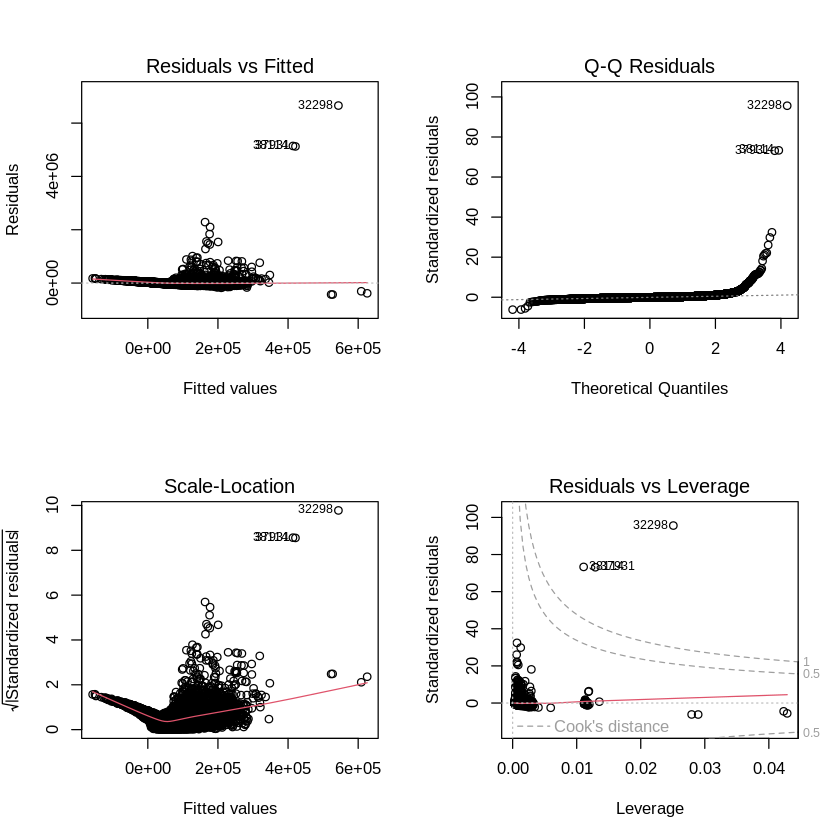

In [ ]:
par(mfrow = c(2,2))
plot(lm_model)

vif(lm_model)

### Transformations

In [ ]:
# If income is skewed
train$log_income <- log(train$person_income)
test$log_income <- log(test$person_income)

In [ ]:
# Refit model
lm_model_log <- lm(log_income ~ . - person_income, data = train)

summary(lm_model_log)


Call:
lm(formula = log_income ~ . - person_income, data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.7414 -0.1213  0.0044  0.1203  3.6496 

Coefficients:
                                    Estimate Std. Error  t value Pr(>|t|)    
(Intercept)                        1.110e+01  2.807e-02  395.413  < 2e-16 ***
person_age                         6.400e-03  8.771e-04    7.296 3.02e-13 ***
person_gendermale                  2.085e-04  2.854e-03    0.073  0.94176    
person_educationBachelor           8.031e-03  3.802e-03    2.112  0.03467 *  
person_educationDoctorate          6.584e-03  1.251e-02    0.526  0.59860    
person_educationHigh School       -1.814e-03  3.892e-03   -0.466  0.64118    
person_educationMaster             5.803e-03  4.582e-03    1.267  0.20534    
person_emp_exp                    -1.342e-03  7.850e-04   -1.710  0.08733 .  
person_home_ownershipOTHER         1.598e-02  2.818e-02    0.567  0.57073    
person_home_ownershipOWN          -1.071e-01 

,GVIF,Df,GVIF^(1/(2*Df))
person_age,14.139611,1,3.760267
person_gender,1.000632,1,1.000316
person_education,1.068411,4,1.008306
person_emp_exp,11.361203,1,3.370638
person_home_ownership,1.218673,3,1.033510
loan_amnt,1.802038,1,1.342400
loan_intent,1.059887,5,1.005833
loan_int_rate,1.160075,1,1.077068
loan_percent_income,2.013628,1,1.419024
cb_person_cred_hist_length,3.798624,1,1.949006


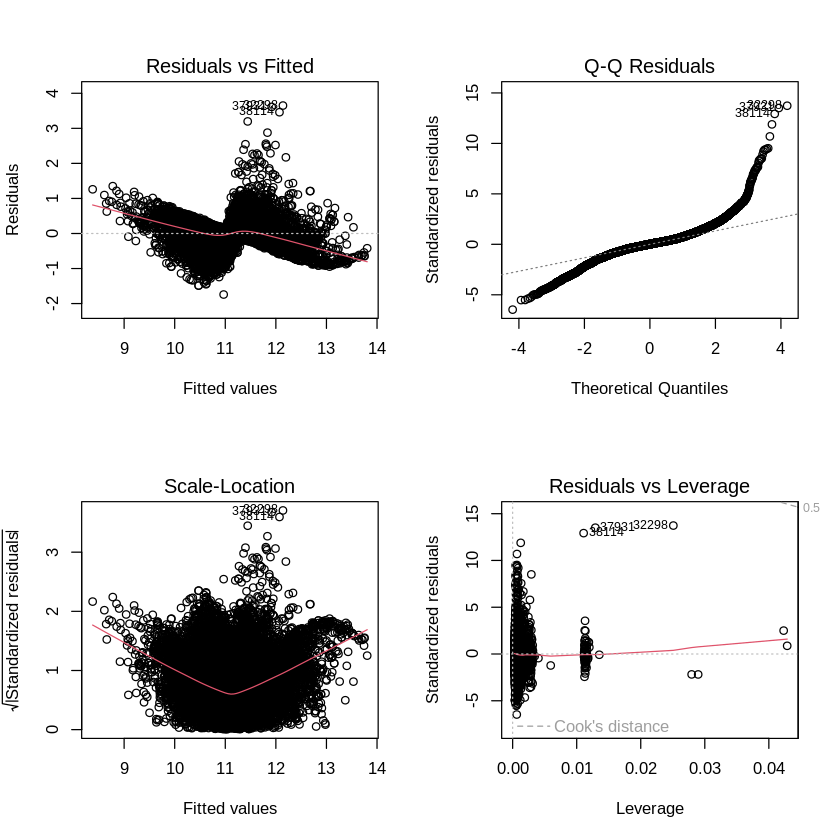

In [ ]:
# Check Assumptions again
par(mfrow = c(2,2))
plot(lm_model_log)

vif(lm_model_log)

### Model Evaluation

In [ ]:
# Prediction
pred <- predict(lm_model_log, newdata = test)

# Convert back
pred_exp <- exp(pred)

# Metrics
RMSE <- sqrt(mean((test$person_income - pred_exp)^2))
MAE <- mean(abs(test$person_income - pred_exp))

RMSE
MAE

[1] 49141.56

[1] 16591.53

### Another model for comparison

In [ ]:
# Step-wise Regression
step_model <- stepAIC(lm_model_log, direction = "both")

summary(step_model)

Start:  AIC=-94469.58
log_income ~ (person_age + person_gender + person_education + 
    person_income + person_emp_exp + person_home_ownership + 
    loan_amnt + loan_intent + loan_int_rate + loan_percent_income + 
    cb_person_cred_hist_length + credit_score + previous_loan_defaults_on_file + 
    loan_status) - person_income

                                 Df Sum of Sq    RSS    AIC
- credit_score                    1       0.0 2607.0 -94472
- person_gender                   1       0.0 2607.0 -94472
- previous_loan_defaults_on_file  1       0.1 2607.0 -94471
<none>                                        2607.0 -94470
- person_education                4       0.6 2607.6 -94469
- person_emp_exp                  1       0.2 2607.2 -94469
- loan_status                     1       0.4 2607.4 -94466
- cb_person_cred_hist_length      1       0.7 2607.7 -94462
- loan_intent                     5       3.7 2610.7 -94428
- person_age                      1       3.9 2610.8 -94418
- loan_i


Call:
lm(formula = log_income ~ person_age + person_education + person_emp_exp + 
    person_home_ownership + loan_amnt + loan_intent + loan_int_rate + 
    loan_percent_income + cb_person_cred_hist_length + loan_status, 
    data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.7425 -0.1215  0.0044  0.1201  3.6501 

Coefficients:
                              Estimate Std. Error  t value Pr(>|t|)    
(Intercept)                  1.110e+01  2.045e-02  542.614  < 2e-16 ***
person_age                   6.398e-03  8.770e-04    7.295 3.05e-13 ***
person_educationBachelor     8.090e-03  3.789e-03    2.135  0.03277 *  
person_educationDoctorate    6.758e-03  1.247e-02    0.542  0.58795    
person_educationHigh School -1.854e-03  3.881e-03   -0.478  0.63295    
person_educationMaster       5.903e-03  4.546e-03    1.298  0.19414    
person_emp_exp              -1.330e-03  7.835e-04   -1.698  0.08953 .  
person_home_ownershipOTHER   1.607e-02  2.818e-02    0.570  0.56852    
pe

### Classification Model

In [ ]:
# Logistic Regression
log_model <- glm(loan_status ~ . - person_income, data = train, family = "binomial")

summary(log_model)


Call:
glm(formula = loan_status ~ . - person_income, family = "binomial", 
    data = train)

Coefficients:
                                    Estimate Std. Error z value Pr(>|z|)    
(Intercept)                        9.856e+00  9.794e-01  10.063  < 2e-16 ***
person_age                         2.536e-02  1.229e-02   2.063   0.0391 *  
person_gendermale                  4.233e-02  3.980e-02   1.064   0.2875    
person_educationBachelor           7.489e-03  5.289e-02   0.142   0.8874    
person_educationDoctorate          1.556e-02  1.668e-01   0.093   0.9257    
person_educationHigh School        4.044e-02  5.529e-02   0.731   0.4646    
person_educationMaster             4.137e-02  6.337e-02   0.653   0.5139    
person_emp_exp                    -1.834e-02  1.089e-02  -1.683   0.0923 .  
person_home_ownershipOTHER         4.514e-01  3.693e-01   1.222   0.2216    
person_home_ownershipOWN          -1.563e+00  1.162e-01 -13.448  < 2e-16 ***
person_home_ownershipRENT          6.765e-01

In [ ]:
# Predictions
prob <- predict(log_model, newdata = test, type = "response")

pred_class <- ifelse(prob > 0.5, 1, 0)

# Confusion Matrix
confusionMatrix(as.factor(pred_class), test$loan_status)

Confusion Matrix and Statistics

          Reference
Prediction    0    1
         0 6546  484
         1  435 1534
                                          
               Accuracy : 0.8979          
                 95% CI : (0.8914, 0.9041)
    No Information Rate : 0.7758          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.7039          
                                          
 Mcnemar's Test P-Value : 0.1133          
                                          
            Sensitivity : 0.9377          
            Specificity : 0.7602          
         Pos Pred Value : 0.9312          
         Neg Pred Value : 0.7791          
             Prevalence : 0.7758          
         Detection Rate : 0.7274          
   Detection Prevalence : 0.7812          
      Balanced Accuracy : 0.8489          
                                          
       'Positive' Class : 0               
                        

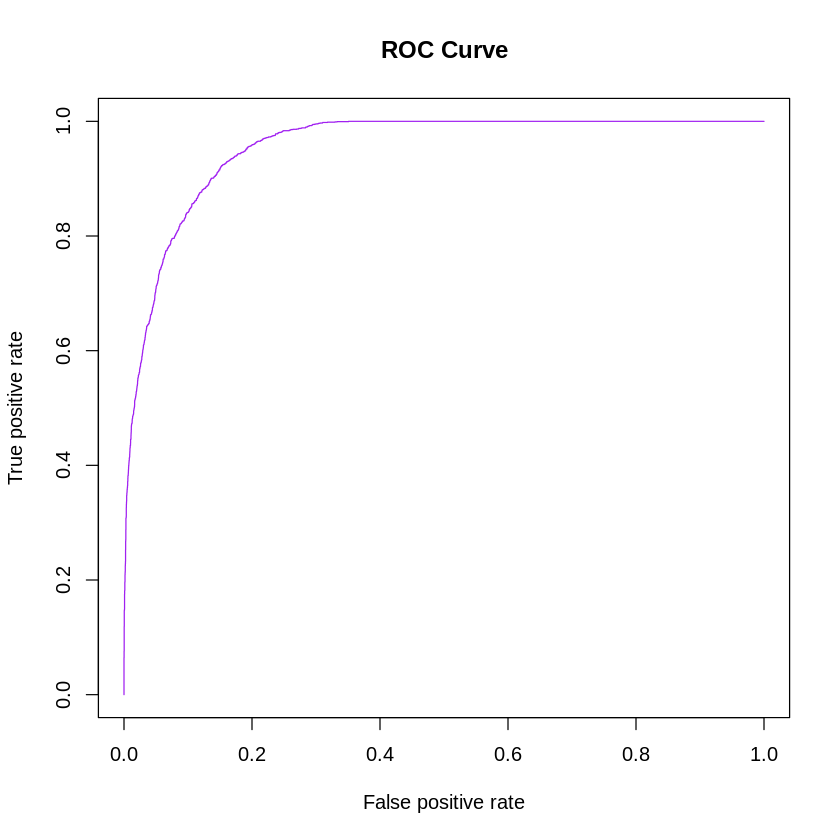

In [ ]:
# ROC Curve
pred_obj <- prediction(prob, test$loan_status)
perf <- performance(pred_obj, "tpr", "fpr")

plot(perf, col = "purple", main = "ROC Curve")

In [ ]:
# Feature Engineering
data$income_per_experience <- data$person_income / (data$person_emp_exp + 1)

data$loan_to_credit_ratio <- data$loan_amnt / data$credit_score